In [3]:
# Importing the libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

# Ignore harmless warnings 

import warnings 
warnings.filterwarnings("ignore")

# Set to display all the columns in dataset

pd.set_option("display.max_columns", None)

# Import psql to run queries 

import pandasql as psql

In [2]:
pip install pandasql

  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26822 sha256=fed65d1382a08e1ccf26eca91cf7adc6b6e6b36a89bd0058804836a16e5ee454
  Stored in directory: c:\users\ranji\appdata\local\pip\cache\wheels\ed\8f\46\a383923333728744f01ba24adbd8e364f2cb9470a8b8e5b9ff
Successfully built pandasql
Note: you may need to restart the kernel to use updated packages.


In [5]:
aug_train = pd.read_csv(r"C:\Users\ranji\Downloads\project\aug_train.csv", header= 0)
aug_train_bk = aug_train.copy()
aug_train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,167647,Male,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0
1,17163,Male,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0
2,32023,Female,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0
3,87447,Female,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0
4,501933,Male,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0


In [6]:
aug_test = pd.read_csv(r"C:\Users\ranji\Downloads\project\aug_test.csv", header= 0)
aug_test_bk = aug_train.copy()
aug_test.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,57782,Female,34,1,39.0,1,1-2 Year,No,38244.0,124.0,146
1,286811,Female,55,1,28.0,0,> 2 Years,Yes,37577.0,122.0,109
2,117823,Male,39,1,28.0,1,1-2 Year,No,24578.0,26.0,63
3,213992,Male,28,1,50.0,1,1-2 Year,No,40507.0,8.0,129
4,324756,Female,24,1,10.0,0,< 1 Year,Yes,36783.0,152.0,201


In [7]:
aug_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382154 entries, 0 to 382153
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    382154 non-null  int64  
 1   Gender                382154 non-null  object 
 2   Age                   382154 non-null  int64  
 3   Driving_License       382154 non-null  int64  
 4   Region_Code           382154 non-null  float64
 5   Previously_Insured    382154 non-null  int64  
 6   Vehicle_Age           382154 non-null  object 
 7   Vehicle_Damage        382154 non-null  object 
 8   Annual_Premium        382154 non-null  float64
 9   Policy_Sales_Channel  382154 non-null  float64
 10  Vintage               382154 non-null  int64  
 11  Response              382154 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 35.0+ MB


In [8]:
aug_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78273 entries, 0 to 78272
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    78273 non-null  int64  
 1   Gender                78273 non-null  object 
 2   Age                   78273 non-null  int64  
 3   Driving_License       78273 non-null  int64  
 4   Region_Code           78273 non-null  float64
 5   Previously_Insured    78273 non-null  int64  
 6   Vehicle_Age           78273 non-null  object 
 7   Vehicle_Damage        78273 non-null  object 
 8   Annual_Premium        78273 non-null  float64
 9   Policy_Sales_Channel  78273 non-null  float64
 10  Vintage               78273 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 6.6+ MB


In [9]:
aug_train.nunique()

id                      382154
Gender                       2
Age                         66
Driving_License              2
Region_Code                 53
Previously_Insured           2
Vehicle_Age                  3
Vehicle_Damage               2
Annual_Premium           48993
Policy_Sales_Channel       156
Vintage                    290
Response                     2
dtype: int64

In [10]:
aug_train['Response'].value_counts()

0    319553
1     62601
Name: Response, dtype: int64

In [11]:
aug_test['Vehicle_Age'].value_counts()

1-2 Year     40805
< 1 Year     34169
> 2 Years     3299
Name: Vehicle_Age, dtype: int64

In [12]:
aug_train.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [13]:
aug_test.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

for col in aug_train.columns:
    if aug_train[col].dtypes=='object':
         aug_train[col]=LE.fit_transform(aug_train[col])

In [19]:
aug_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382154 entries, 0 to 382153
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    382154 non-null  int64  
 1   Gender                382154 non-null  int32  
 2   Age                   382154 non-null  int64  
 3   Driving_License       382154 non-null  int64  
 4   Region_Code           382154 non-null  float64
 5   Previously_Insured    382154 non-null  int64  
 6   Vehicle_Age           382154 non-null  int32  
 7   Vehicle_Damage        382154 non-null  int32  
 8   Annual_Premium        382154 non-null  float64
 9   Policy_Sales_Channel  382154 non-null  float64
 10  Vintage               382154 non-null  int64  
 11  Response              382154 non-null  int64  
dtypes: float64(3), int32(3), int64(6)
memory usage: 30.6 MB


In [20]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

for col in aug_test.columns:
    if aug_test[col].dtypes=='object':
         aug_test[col]=LE.fit_transform(aug_test[col])

In [21]:
aug_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78273 entries, 0 to 78272
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    78273 non-null  int64  
 1   Gender                78273 non-null  int32  
 2   Age                   78273 non-null  int64  
 3   Driving_License       78273 non-null  int64  
 4   Region_Code           78273 non-null  float64
 5   Previously_Insured    78273 non-null  int64  
 6   Vehicle_Age           78273 non-null  int32  
 7   Vehicle_Damage        78273 non-null  int32  
 8   Annual_Premium        78273 non-null  float64
 9   Policy_Sales_Channel  78273 non-null  float64
 10  Vintage               78273 non-null  int64  
dtypes: float64(3), int32(3), int64(5)
memory usage: 5.7 MB


In [23]:
# Identify the independent and Target (dependent) variables

IndepVar = []
for col in aug_train.columns:
    if col != 'Response':
        IndepVar.append(col)

TargetVar = 'Response'

x = aug_train[IndepVar]
y = aug_train[TargetVar]

In [24]:
# Splitting the dataset into train and test 

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state = 42)

In [25]:
# Scaling the features by using MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

mmscaler = MinMaxScaler(feature_range=(0, 1))

x_train = mmscaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train)

x_test = mmscaler.fit_transform(x_test)
x_test = pd.DataFrame(x_test)

In [28]:
EMResults = pd.read_csv(r"C:\Users\ranji\Downloads\EMResults (1).csv", header=0)
EMResults.head()

,Model Name,True_Positive,False_Negative,False_Positive,True_Negative,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,ROC_AUC_Score,Balanced Accuracy


Model Name:  LogisticRegression()
Confusion matrix : 
 [[ 8244 10650]
 [ 3054 92699]]
Outcome values : 
 8244 10650 3054 92699
Classification report : 
               precision    recall  f1-score   support

           1       0.73      0.44      0.55     18894
           0       0.90      0.97      0.93     95753

    accuracy                           0.88    114647
   macro avg       0.81      0.70      0.74    114647
weighted avg       0.87      0.88      0.87    114647

Accuracy : 88.0 %
Precision : 73.0 %
Recall : 43.6 %
F1 Score : 0.546
Specificity or True Negative Rate : 96.8 %
Balanced Accuracy : 70.2 %
MCC : 0.503
roc_auc_score: 0.702


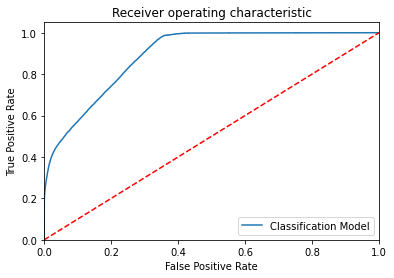

-----------------------------------------------------------------------------------------------------
Model Name:  DecisionTreeClassifier()
Confusion matrix : 
 [[10919  7975]
 [ 8742 87011]]
Outcome values : 
 10919 7975 8742 87011
Classification report : 
               precision    recall  f1-score   support

           1       0.56      0.58      0.57     18894
           0       0.92      0.91      0.91     95753

    accuracy                           0.85    114647
   macro avg       0.74      0.74      0.74    114647
weighted avg       0.86      0.85      0.86    114647

Accuracy : 85.4 %
Precision : 55.5 %
Recall : 57.8 %
F1 Score : 0.566
Specificity or True Negative Rate : 90.9 %
Balanced Accuracy : 74.4 %
MCC : 0.479
roc_auc_score: 0.743


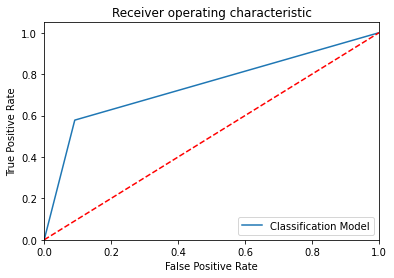

-----------------------------------------------------------------------------------------------------
Model Name:  RandomForestClassifier()
Confusion matrix : 
 [[ 8113 10781]
 [ 1377 94376]]
Outcome values : 
 8113 10781 1377 94376
Classification report : 
               precision    recall  f1-score   support

           1       0.85      0.43      0.57     18894
           0       0.90      0.99      0.94     95753

    accuracy                           0.89    114647
   macro avg       0.88      0.71      0.76    114647
weighted avg       0.89      0.89      0.88    114647

Accuracy : 89.4 %
Precision : 85.5 %
Recall : 42.9 %
F1 Score : 0.572
Specificity or True Negative Rate : 98.6 %
Balanced Accuracy : 70.8 %
MCC : 0.559
roc_auc_score: 0.708


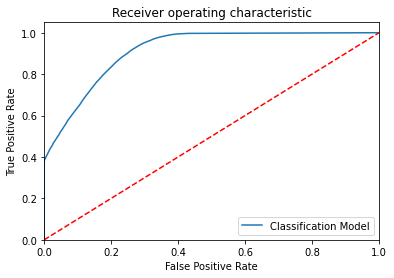

-----------------------------------------------------------------------------------------------------
Model Name:  ExtraTreesClassifier()
Confusion matrix : 
 [[ 8322 10572]
 [ 1899 93854]]
Outcome values : 
 8322 10572 1899 93854
Classification report : 
               precision    recall  f1-score   support

           1       0.81      0.44      0.57     18894
           0       0.90      0.98      0.94     95753

    accuracy                           0.89    114647
   macro avg       0.86      0.71      0.75    114647
weighted avg       0.88      0.89      0.88    114647

Accuracy : 89.1 %
Precision : 81.4 %
Recall : 44.0 %
F1 Score : 0.572
Specificity or True Negative Rate : 98.0 %
Balanced Accuracy : 71.0 %
MCC : 0.548
roc_auc_score: 0.71


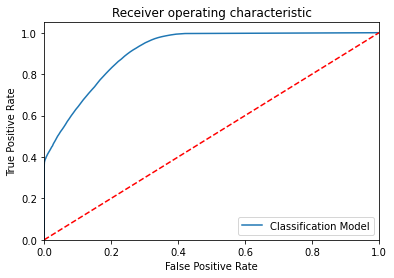

-----------------------------------------------------------------------------------------------------


In [29]:
# Build the Calssification models and compare the results

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.naive_bayes import GaussianNB
#from xgboost import XGBClassifier
# import lightgbm as lgb

# Create objects of classification algorithm with default hyper-parameters

ModelLR = LogisticRegression()
ModelDC = DecisionTreeClassifier()
ModelRF = RandomForestClassifier()
ModelET = ExtraTreesClassifier()
#ModelKNN = KNeighborsClassifier(n_neighbors=5)
#ModelGNB = GaussianNB()
#ModelXGB = XGBClassifier(n_estimators=100, max_depth=3, eval_metric='mlogloss')
#ModelLGB = lgb.LGBMClassifier()

# Evalution matrix for all the algorithms

#MM = [ModelLR, ModelDC, ModelRF, ModelET, ModelKNN, ModelGNB, ModelSVM, modelXGB, modelLGB]
MM = [ModelLR, ModelDC, ModelRF, ModelET]
for models in MM:
    
    # Fit the model
    
    models.fit(x_train, y_train)
    
    # Prediction
    
    y_pred = models.predict(x_test)
    y_pred_prob = models.predict_proba(x_test)
    
    # Print the model name
    
    print('Model Name: ', models)
    
    # confusion matrix in sklearn

    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import classification_report

    # actual values

    actual = y_test

    # predicted values

    predicted = y_pred

    # confusion matrix

    matrix = confusion_matrix(actual,predicted, labels=[1,0],sample_weight=None, normalize=None)
    print('Confusion matrix : \n', matrix)

    # outcome values order in sklearn

    tp, fn, fp, tn = confusion_matrix(actual,predicted,labels=[1,0]).reshape(-1)
    print('Outcome values : \n', tp, fn, fp, tn)

    # classification report for precision, recall f1-score and accuracy

    C_Report = classification_report(actual,predicted,labels=[1,0])

    print('Classification report : \n', C_Report)

    # calculating the metrics

    sensitivity = round(tp/(tp+fn), 3);
    specificity = round(tn/(tn+fp), 3);
    accuracy = round((tp+tn)/(tp+fp+tn+fn), 3);
    balanced_accuracy = round((sensitivity+specificity)/2, 3);
    
    precision = round(tp/(tp+fp), 3);
    f1Score = round((2*tp/(2*tp + fp + fn)), 3);

    # Matthews Correlation Coefficient (MCC). Range of values of MCC lie between -1 to +1. 
    # A model with a score of +1 is a perfect model and -1 is a poor model

    from math import sqrt

    mx = (tp+fp) * (tp+fn) * (tn+fp) * (tn+fn)
    MCC = round(((tp * tn) - (fp * fn)) / sqrt(mx), 3)

    print('Accuracy :', round(accuracy*100, 2),'%')
    print('Precision :', round(precision*100, 2),'%')
    print('Recall :', round(sensitivity*100,2), '%')
    print('F1 Score :', f1Score)
    print('Specificity or True Negative Rate :', round(specificity*100,2), '%'  )
    print('Balanced Accuracy :', round(balanced_accuracy*100, 2),'%')
    print('MCC :', MCC)

    # Area under ROC curve 

    from sklearn.metrics import roc_curve, roc_auc_score

    print('roc_auc_score:', round(roc_auc_score(actual, predicted), 3))
    
    # ROC Curve
    
    from sklearn.metrics import roc_auc_score
    from sklearn.metrics import roc_curve
    model_roc_auc = roc_auc_score(actual, predicted)
    fpr, tpr, thresholds = roc_curve(actual, models.predict_proba(x_test)[:,1])
    plt.figure()
    # plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
    plt.plot(fpr, tpr, label= 'Classification Model' % model_roc_auc)
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right")
    plt.savefig('Log_ROC')
    plt.show()
    print('-----------------------------------------------------------------------------------------------------')
    #---
    new_row = {'Model Name' : models,
               'True_Positive' : tp, 
               'False_Negative' : fn, 
               'False_Positive' : fp,
               'True_Negative' : tn,
               'Accuracy' : accuracy,
               'Precision' : precision,
               'Recall' : sensitivity,
               'F1 Score' : f1Score,
               'Specificity' : specificity,
               'MCC':MCC,
               'ROC_AUC_Score':roc_auc_score(actual, predicted),
               'Balanced Accuracy':balanced_accuracy}
    EMResults = EMResults.append(new_row, ignore_index=True)
    #---

In [30]:
EMResults.head()

,Model Name,True_Positive,False_Negative,False_Positive,True_Negative,Accuracy,Precision,Recall,F1 Score,Specificity,MCC,ROC_AUC_Score,Balanced Accuracy
0,LogisticRegression(),8244,10650,3054,92699,0.880,0.730,0.436,0.546,0.968,0.503,0.702217,0.702
1,DecisionTreeClassifier(),10919,7975,8742,87011,0.854,0.555,0.578,0.566,0.909,0.479,0.743305,0.744
2,"(DecisionTreeClassifier(max_features='auto', r...",8113,10781,1377,94376,0.894,0.855,0.429,0.572,0.986,0.559,0.707507,0.708
3,"(ExtraTreeClassifier(random_state=1171765963),...",8322,10572,1899,93854,0.891,0.814,0.440,0.572,0.980,0.548,0.710313,0.710
